Домашнее задание: Решающие деревья, ансамбли и бустинг

Датасет: [Bank Marketing Dataset](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset) (предсказание, подпишется ли клиент на депозит)

In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
Path to dataset files: /kaggle/input/bank-marketing-dataset


Первичный анализ данных ( 1 балл)

- Загрузите данные и выполните первичный анализ

- Проведите анализ распределения целевой переменной

- Выявите и обработайте пропущенные значения в данных
- Преобразуй категориальные данные в числовые (LabelEncoder)
- Разделите данные на обучающую и тестовую выборки в соотношении 80/20


In [25]:
import os
import pandas as pd

print(os.listdir(path))
data = pd.read_csv(f'{path}/{os.listdir(path)[0]}')
data.head()

['bank.csv']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [26]:
yes_no_cols = [col for col in data.columns if set(data[col].unique()) <= {"yes", "no"}]
for col in yes_no_cols:
  data[col] = data[col].map({"yes": 1, "no": 0})

data.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
1,56,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,1
2,41,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,1
3,55,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,1
4,54,admin.,married,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,unknown,1


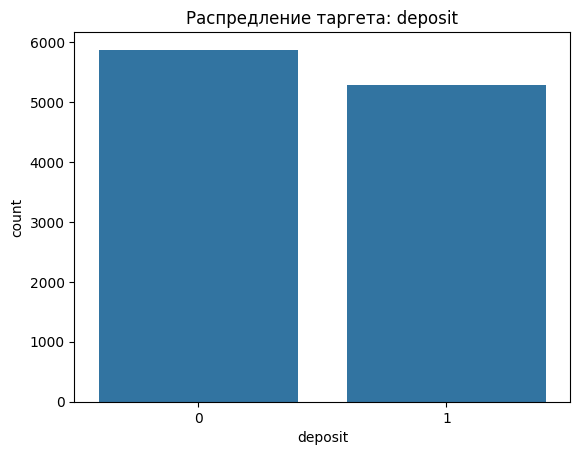

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=data, x="deposit")
plt.title("Распредление таргета: deposit")
plt.xlabel("deposit")
plt.ylabel("count")
plt.show()

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  int64 
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  int64 
 7   loan       11162 non-null  int64 
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  int64 
dtypes: int64(11), object(6)
memory usage: 1.4+ MB


In [29]:
print(data['job'].unique())
job_arr = ['unknown', 'unemployed', 'technician', 'student', 'services', 'self-employed', 'retired', 'management', 'housemaid', 'entrepreneur', 'blue-collar', 'admin.']
data["job"] = data["job"].map({v: i for i, v in enumerate(job_arr)})
data.head()

['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,11,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
1,56,11,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,1
2,41,2,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,1
3,55,4,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,1
4,54,11,married,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,unknown,1


In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["marital"] = le.fit_transform(data["marital"])
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,11,1,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,unknown,1
1,56,11,1,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,unknown,1
2,41,2,1,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,unknown,1
3,55,4,1,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,unknown,1
4,54,11,1,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,unknown,1


In [31]:
data['education'] = le.fit_transform(data["education"])
data['contact'] = le.fit_transform(data["contact"])
data['poutcome'] = le.fit_transform(data["poutcome"])
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,11,1,1,0,2343,1,0,2,5,may,1042,1,-1,0,3,1
1,56,11,1,1,0,45,0,0,2,5,may,1467,1,-1,0,3,1
2,41,2,1,1,0,1270,1,0,2,5,may,1389,1,-1,0,3,1
3,55,4,1,1,0,2476,1,0,2,5,may,579,1,-1,0,3,1
4,54,11,1,2,0,184,0,0,2,5,may,673,2,-1,0,3,1


In [32]:
print(data['month'].unique())
month_arr = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
data["month"] = data["month"].map({v: i for i, v in enumerate(month_arr)})
data.head()

['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,11,1,1,0,2343,1,0,2,5,4,1042,1,-1,0,3,1
1,56,11,1,1,0,45,0,0,2,5,4,1467,1,-1,0,3,1
2,41,2,1,1,0,1270,1,0,2,5,4,1389,1,-1,0,3,1
3,55,4,1,1,0,2476,1,0,2,5,4,579,1,-1,0,3,1
4,54,11,1,2,0,184,0,0,2,5,4,673,2,-1,0,3,1


In [33]:
from sklearn.model_selection import train_test_split

X = data.drop('deposit', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, data['deposit'], test_size=0.2, stratify=data['deposit'])
print(X_train.shape)
print(X_test.shape)

(8929, 16)
(2233, 16)


Часть 1: Решающие деревья ( 3 балла)

Постройте решающее дерево для классификации с максимальной глубиной 3. Визуализируйте дерево и ответьте:

- Какие 3 признака оказались самыми важными на верхнем уровне дерева?

- Какой лист содержит наибольшее количество объектов и каково его предсказание?

0.7693685624720108
[[921 254]
 [261 797]]
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      1175
           1       0.76      0.75      0.76      1058

    accuracy                           0.77      2233
   macro avg       0.77      0.77      0.77      2233
weighted avg       0.77      0.77      0.77      2233



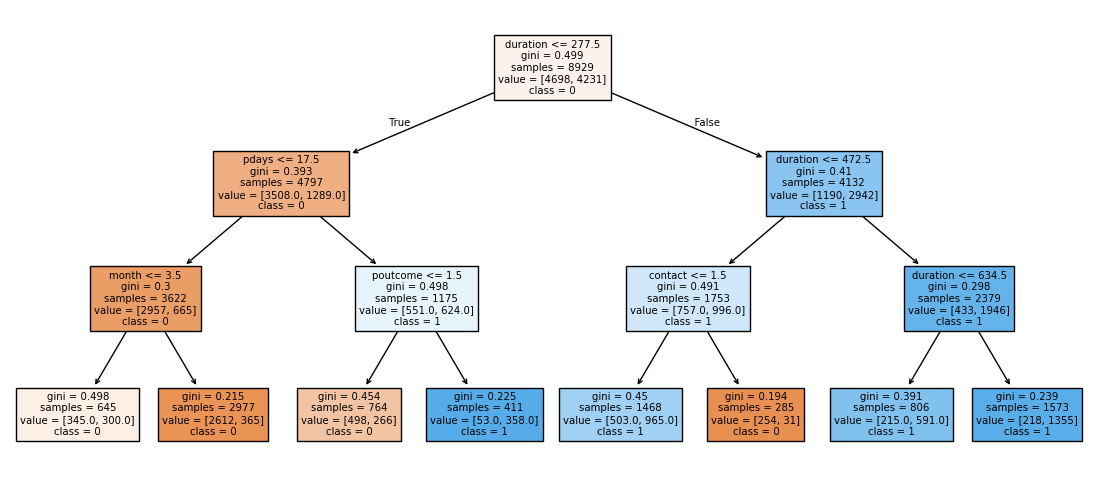

Топ-3 признака: ['duration', 'pdays', 'month']
Самый большой лист -  4 количество объектов: 2977 его предсказание: 0


In [34]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

dec_tree_acc = accuracy_score(y_test, y_pred)
dec_tree_matrix = confusion_matrix(y_test, y_pred)
dec_tree_report = classification_report(y_test, y_pred)

print(dec_tree_acc)
print(dec_tree_matrix)
print(dec_tree_report)

plt.figure(figsize=(14, 6))
plot_tree(model, feature_names=X_train.columns, class_names=["0", "1"], filled=True)
plt.show()

tree = model.tree_
top_nodes = [0, 1, 2]
print("Топ-3 признака:", [X_train.columns[i] for i in tree.feature[top_nodes]])

leaf_indices = np.where(tree.children_left == -1)[0]
best_leaf = leaf_indices[tree.n_node_samples[leaf_indices].argmax()]
prediction = tree.value[best_leaf].argmax()

print("Самый большой лист - ", best_leaf, "количество объектов:", tree.n_node_samples[best_leaf], "его предсказание:", prediction)

Ответ на вопрос:  
Самый большой лист -  4 количество объектов: 2353 его предсказание: 0

- Проведите эксперимент с разной глубиной дерева (от 2 до 10). Постройте график:

Ось X: глубина дерева

Ось Y: accuracy на тренировочной и тестовой выборках

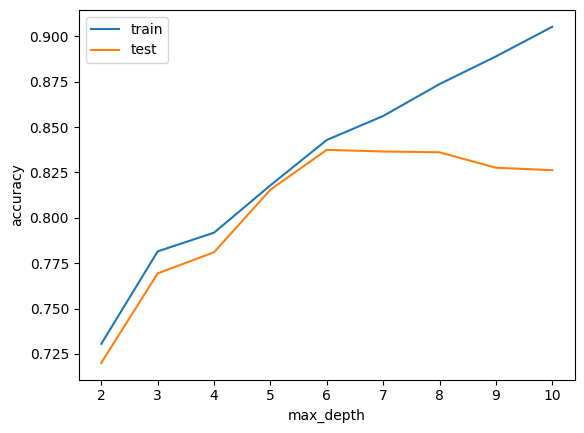

In [35]:
acc_arr_train = []
acc_arr_test = []

for i in range(2, 11):
  model = DecisionTreeClassifier(max_depth=i)
  model.fit(X_train, y_train)
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  acc_arr_train.append(accuracy_score(y_train, y_train_pred))
  acc_arr_test.append(accuracy_score(y_test, y_test_pred))


plt.plot(range(2, 11), acc_arr_train, label="train")
plt.plot(range(2, 11), acc_arr_test, label="test")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.legend()
plt.show()


- Объясните, наблюдаете ли вы переобучение. На какой глубине оно начинает проявляться?
- Сравните поведение accuracy на тренировочной и тестовой выборках.

Ответ на вопрос:  
Конечно, наблюдается переобучение. Это начинается с depth=6, train все так же растет,  а вот test acc остается +- таким же.  
Также на графике отлично видно, что depth=2 недостаточно, недообучение. Далее с увеличением max_depth происходит одновременное уввеличение acc у всего датасета, ну и потом переобучение. Оптимальным параметром считаю max_depth=5.

Часть 2: Случайный лес ( 3 балла)

Обучите случайный лес с 100 деревьями. Сравните его производительность с лучшим одиночным деревом из Части 1.

- На сколько процентов улучшилась accuracy?

- Как изменилось переобучение?

In [36]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rf_train_acc = accuracy_score(y_train, model.predict(X_train))
rf_test_acc  = accuracy_score(y_test,  y_pred)

rand_f_matrix = confusion_matrix(y_test, y_pred)
rand_f_report = classification_report(y_test, y_pred)

print(rf_test_acc)
print(rand_f_matrix)
print(rand_f_report)

0.8526645768025078
[[961 214]
 [115 943]]
              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1175
           1       0.82      0.89      0.85      1058

    accuracy                           0.85      2233
   macro avg       0.85      0.85      0.85      2233
weighted avg       0.86      0.85      0.85      2233



In [37]:
model2 = DecisionTreeClassifier(max_depth=5)
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)
dt_train_acc = accuracy_score(y_train, model2.predict(X_train))
dt_test_acc  = accuracy_score(y_test,  y_pred)

dec_tree_acc = accuracy_score(y_test, y_pred)
dec_tree_matrix = confusion_matrix(y_test, y_pred)
dec_tree_report = classification_report(y_test, y_pred)
print(dec_tree_acc)
print(dec_tree_matrix)
print(dec_tree_report)

0.8154948499776086
[[960 215]
 [197 861]]
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      1175
           1       0.80      0.81      0.81      1058

    accuracy                           0.82      2233
   macro avg       0.81      0.82      0.82      2233
weighted avg       0.82      0.82      0.82      2233



In [38]:
upgrade = (rf_test_acc - dt_test_acc) / dt_test_acc * 100
print("На сколько процентов улучшилась accuracy? ", upgrade, "%")

gap_dt = dt_train_acc - dt_test_acc
gap_rf = rf_train_acc - rf_test_acc

print("Переобучение на DT: ", gap_dt)
print("Переобучение на RF: ", gap_rf)

На сколько процентов улучшилась accuracy?  4.557935200439323 %
Переобучение на DT:  0.0024018909788254827
Переобучение на RF:  0.14733542319749215


- Проанализируйте важность признаков в случайном лесе.
 - Сравните ТОП-5 признаков с ТОП-5 из одиночного дерева. Объясните, почему списки могут отличаться.

In [39]:
rf_imp_5 = model.feature_importances_
dt_imp_5 = model2.feature_importances_

rf_top_idx = np.argsort(rf_imp_5)[-5:][::-1]
dt_top_idx = np.argsort(dt_imp_5)[-5:][::-1]

print("Топ-5 признаков RF:")
for i in rf_top_idx:
    print(X_train.columns[i], rf_imp_5[i])

print("\nТоп-5 признаков DT:")
for i in dt_top_idx:
    print(X_train.columns[i], dt_imp_5[i])

Топ-5 признаков RF:
duration 0.36344748273655325
month 0.08712813931426044
balance 0.08552013369089581
age 0.08348592118072337
day 0.07803472827386974

Топ-5 признаков DT:
duration 0.5219032443108924
month 0.12962749537724932
pdays 0.10739591220890164
contact 0.07706065785269876
poutcome 0.06929255446795857


Скорее всего они отчаются из-за того, что мы в самом начале наэнкодили там всякого, могло повлиять, чтоб моделька приняла рандомные числа за важные признаки, такие как contact и poutcome. ну бывает)

Часть 3: Градиентный бустинг ( 3 балла)

- Обучите модель градиентного бустинга (CatBoost или XGBoost). Проведите эксперимент с learning rate:

   *  learning rate = 0.01

   * learning rate = 0.1

   * learning rate = 0.3




In [40]:
!pip install catboost

In [41]:
from catboost import CatBoostClassifier

lr = [0.01, 0.1, 0.3]
train_accs = []
test_accs = []
for i in lr:
  model = CatBoostClassifier(learning_rate=i, iterations=200, depth=6, loss_function="Logloss", verbose=False)
  model.fit(X_train, y_train)

  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  train_acc = accuracy_score(y_train, y_train_pred)
  test_acc = accuracy_score(y_test,  y_test_pred)
  train_accs.append(train_acc)
  test_accs.append(test_acc)

  print('lr =', i)
  print('Train acc: ', train_acc)
  print('Test acc: ', test_acc)
  print()

lr = 0.01
Train acc:  0.8351439130921716
Test acc:  0.8293775190326914

lr = 0.1
Train acc:  0.8981968865494456
Test acc:  0.8616211374832065

lr = 0.3
Train acc:  0.95609810729085
Test acc:  0.8504254366323332



По результатам эксперимента лучше всего отработал lr = 0.1, и gap меньше всего, а качество на тесте самое хорошее, а вот на 0.3 уже переобучение начинается.

- Сравните бустинг со случайным лесом по следующим параметрам:

    - Точность (accuracy)
    - Интерпретируемость

По точности выигрывает бустинг (0.8629646215853113 против 0.8472906403940886), хотя не сильно большая разница, возможно дотянуть рандом форест до бустинга, но с натяжкой.  
А вот по интерпретируемости я считаю выигрывает рандом форест потому что это более легкая модель.

- Примените технику Target Encoding к категориальным признакам в CatBoost.
- Сравните результаты с one-hot encoding.
- Какой метод показал лучшую производительность и напиши выводы?



In [42]:
cat_cols = ["job", "marital", "education", "contact", "month", "poutcome"]

model_te = CatBoostClassifier(learning_rate=0.1, iterations=200, depth=6, loss_function="Logloss", verbose=False)
model_te.fit(X_train, y_train, cat_features=cat_cols)
y_test_pred_te = model_te.predict(X_test)
print('Accuracy with target enc: ', accuracy_score(y_test, y_test_pred_te))

Accuracy with target enc:  0.8598298253470668


In [43]:
X_train_ohe = pd.get_dummies(X_train, columns=cat_cols)
X_test_ohe = pd.get_dummies(X_test, columns=cat_cols)
X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join="left", axis=1, fill_value=0)

model_ohe = CatBoostClassifier(learning_rate=0.1, iterations=200, depth=6, loss_function="Logloss", verbose=False)
model_ohe.fit(X_train_ohe, y_train)
y_test_pred_ohe = model_ohe.predict(X_test_ohe)
print('Accuracy with one-hot enc: ', accuracy_score(y_test, y_test_pred_ohe))

Accuracy with one-hot enc:  0.864755933721451


Выводы:  
У te accuracy больше, но это было гораздо дольше, чем ohe, хотя качество отличается не прям сильно. но ohe еще сложнее пишется на мой взгляд, я бы выбрала все равно te, он кажется мне более логичным.